In [1]:
import scarf
from scarf.plotting import CellField, FeatureRef

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "swanson_7K_pbmc_teaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", default_assay="RNA", nthreads=4)

Downloading bucket files: 487959744 / 487959744 complete

Downloading bytes: 487959744 / 487959744 complete

RNA


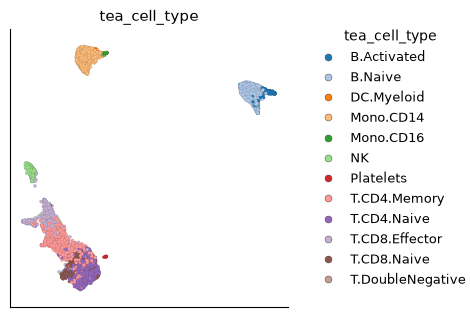

ATAC


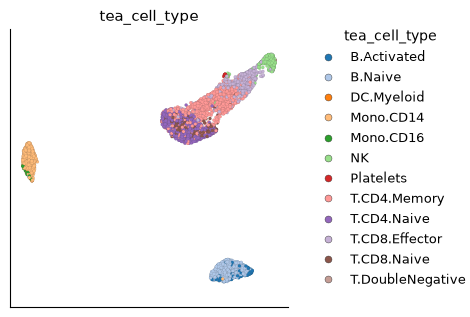

ADT


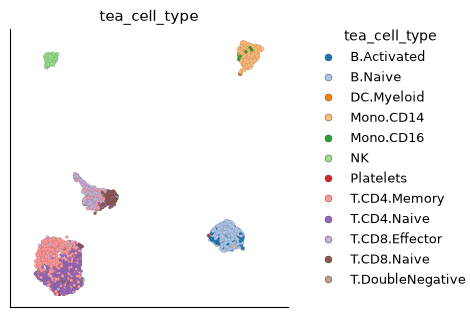

In [2]:
for assay in ("RNA", "ATAC", "ADT"):
    [layout] = ds.list_artifacts(
        from_assay=assay,
        kind="embedding",
        operation="run_umap",
        complete_only=True,
    )
    print(assay)
    ds.plots.embedding(layout=layout, color_by="tea_cell_type")

In [3]:
[wnn_graph] = ds.list_artifacts(
    scope="datastore",
    kind="integrated_graph",
    operation="integrate_assays",
    parameters={"method": "wnn"},
    complete_only=True,
)
[wnn_layout] = ds.list_artifacts(
    scope="datastore",
    kind="embedding",
    operation="run_umap",
    inputs={"graph": wnn_graph},
    complete_only=True,
)

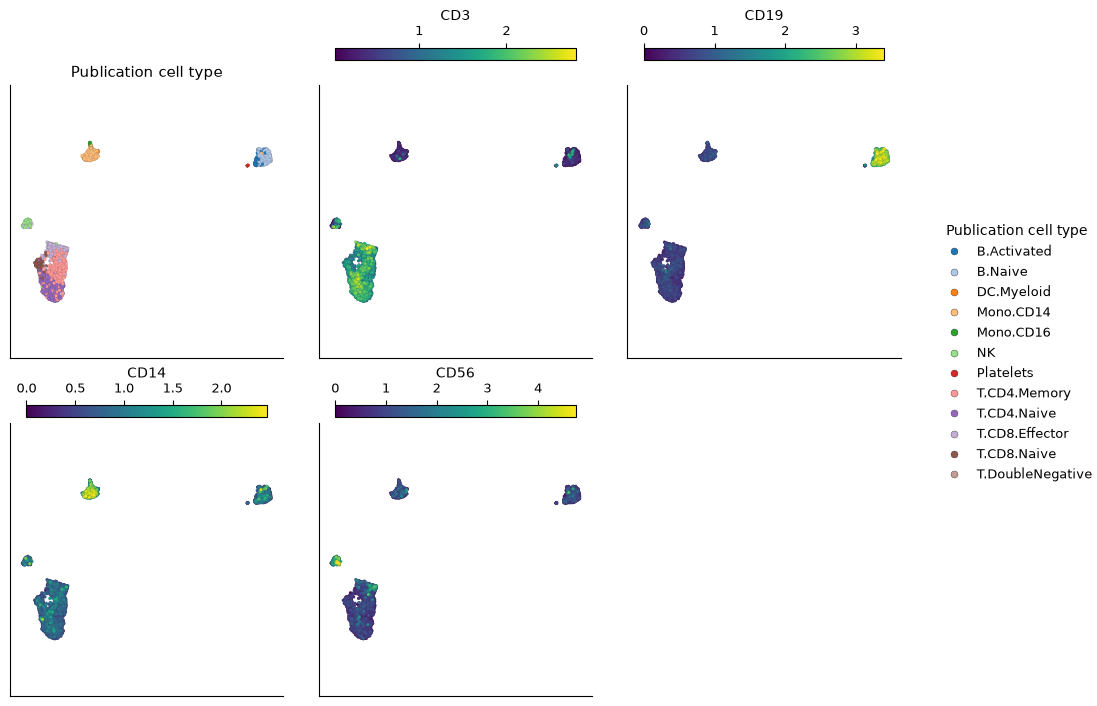

In [4]:
ds.plots.embedding(
    layout=wnn_layout,
    color_by=[
        CellField("tea_cell_type", label="Publication cell type"),
        FeatureRef("CD3", assay="ADT"),
        FeatureRef("CD19", assay="ADT"),
        FeatureRef("CD14", assay="ADT"),
        FeatureRef("CD56", assay="ADT"),
    ],
    n_columns=3,
    sort_values=True,
)

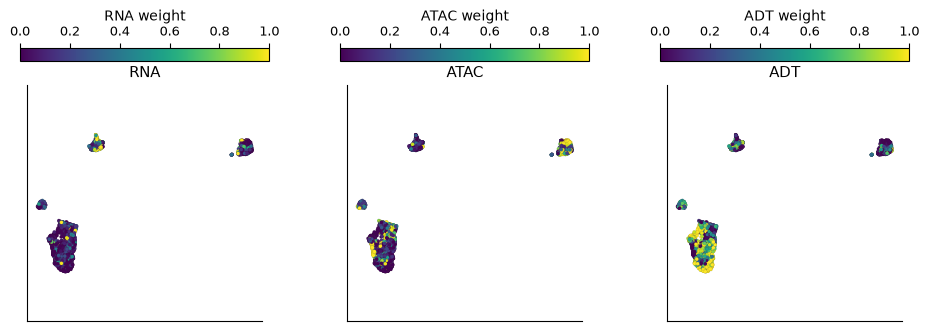

In [5]:
ds.plots.modality_weights(graph=wnn_graph, layout=wnn_layout)